<a href="https://colab.research.google.com/github/riku05190/riku-nakamura.github.io/blob/main/Module5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!echo "Downloading files..."
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training1.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training2.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout_answers.csv

In [21]:
!echo "Unzipping files..."
!unzip -q -o /content/training1.zip
!unzip -q -o /content/training2.zip
!unzip -q -o /content/holdout.zip
!unzip -q -o /content/mini_holdout.zip

Unzipping files...


In [22]:
!echo "Merging training data..."
!mkdir -p /content/training
!mv /content/training1/* /content/training/ 2>/dev/null || true
!mv /content/training2/* /content/training/ 2>/dev/null || true

Merging training data...


In [23]:
!echo "Cleaning up..."
!rm -rf /content/training1
!rm -rf /content/training2
!rm training1.zip
!rm training2.zip
!rm holdout.zip
!rm mini_holdout.zip
!echo "Data ready."

Cleaning up...
Data ready.


In [24]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

In [25]:
training_dir = '/content/training/'
image_size = (128, 128)
batch_size_config = 32
num_classes = 43

In [26]:
train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=15,
zoom_range=0.15,
width_shift_range=0.1,
height_shift_range=0.1,
validation_split=0.2
)

In [27]:
validation_datagen = ImageDataGenerator(
rescale=1./255,
validation_split=0.2
)

In [28]:
train_generator = train_datagen.flow_from_directory(
training_dir,
target_size=image_size,
subset="training",
batch_size=batch_size_config,
class_mode='sparse',
seed=42,
shuffle=True
)

Found 31368 images belonging to 43 classes.


In [29]:
validation_generator = validation_datagen.flow_from_directory(
training_dir,
target_size=image_size,
batch_size=batch_size_config,
class_mode='sparse',
subset="validation",
seed=42
)

Found 7841 images belonging to 43 classes.


In [30]:
target_names = ['Speed_20', 'Speed_30', 'Speed_50', 'Speed_60', 'Speed_70',
'Speed_80','Speed_Limit_Ends', 'Speed_100', 'Speed_120', 'Overtaking_Prohibited',
'Overtakeing_Prohibited_Trucks', 'Priority', 'Priority_Road_Ahead', 'Yield', 'STOP',
'Entry_Forbidden', 'Trucks_Forbidden', 'No_Entry(one-way traffic)', 'General Danger(!)', 'Left_Curve_Ahead',
'Right_Curve_Ahead', 'Double_Curve', 'Poor_Surface_Ahead', 'Slippery_Surface_Ahead', 'Road_Narrows_On_Right',
'Roadwork_Ahead', 'Traffic_Light_Ahead', 'Warning_Pedestrians', 'Warning_Children', 'Warning_Bikes',
'Ice_Snow', 'Deer_Crossing', 'End_Previous_Limitation', 'Turning_Right_Compulsory', 'Turning_Left_Compulsory',
'Ahead_Only', 'Straight_Or_Right_Mandatory', 'Straight_Or_Left_Mandatory', 'Passing_Right_Compulsory', 'Passing_Left_Compulsory',
'Roundabout', 'End_Overtaking_Prohibition', 'End_Overtaking_Prohibition_Trucks']

In [31]:
plt.figure(figsize=(10, 10))
images, labels = next(train_generator)

<Figure size 1000x1000 with 0 Axes>

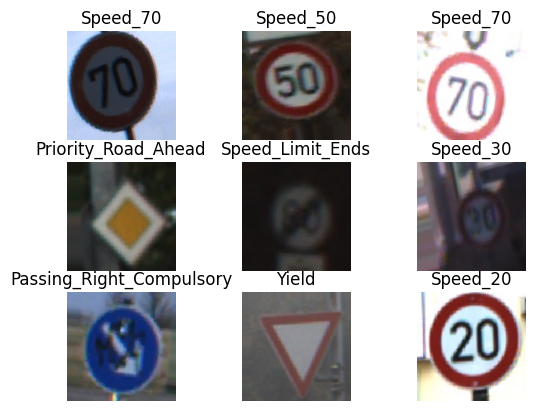

In [32]:
for i in range(min(9, images.shape[0])):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(target_names[int(labels[i])])
    plt.axis("off")
plt.show()

In [34]:
def build_gehirnwagen_model():
    base_model = applications.MobileNetV2(
        input_shape=(image_size[0], image_size[1], 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

In [36]:
def build_gehirnwagen_model():
    base_model = applications.MobileNetV2(
        input_shape=(image_size[0], image_size[1], 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(image_size[0], image_size[1], 3)),
        layers.Lambda(lambda x: (x * 2.0) - 1.0),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [37]:
model = build_gehirnwagen_model()

print("Setting up optimization callbacks...")
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

early_stop = EarlyStopping(
monitor='val_loss',
patience=4,
restore_best_weights=True
)

Setting up optimization callbacks...


In [38]:
history = model.fit(
train_generator,
epochs=15,
validation_data=validation_generator,
callbacks=[tensorboard_callback, early_stop]
)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 741s 748ms/step - accuracy: 0.6536 - loss: 1.1083 - val_accuracy: 0.6407 - val_loss: 1.1703
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 726s 740ms/step - accuracy: 0.7999 - loss: 0.5944 - val_accuracy: 0.6611 - val_loss: 1.1978
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 714s 728ms/step - accuracy: 0.8308 - loss: 0.5007 - val_accuracy: 0.6632 - val_loss: 1.1744
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 711s 724ms/step - accuracy: 0.8381 - loss: 0.4676 - val_accuracy: 0.6731 - val_loss: 1.2150
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 705s 718ms/step - accuracy: 0.8449 - loss: 0.4466 - val_accuracy: 0.6763 - val_loss: 1.2211


In [40]:
model_save_path = "/content/saved_gehirnwagen_model.keras"
model.save(model_save_path)

print("=")
print("PIPELINE EXECUTION SUCCESSFUL")
print("=")
print("Model saved successfully at: " + model_save_path)
print("TensorBoard logs generated at: " + log_dir)
print("The AI team can now import this directory into coremltools for Apple CarKit integration.")
print("=========================================================")

=
PIPELINE EXECUTION SUCCESSFUL
=
Model saved successfully at: /content/saved_gehirnwagen_model.keras
TensorBoard logs generated at: logs/fit/20260621-010050
The AI team can now import this directory into coremltools for Apple CarKit integration.


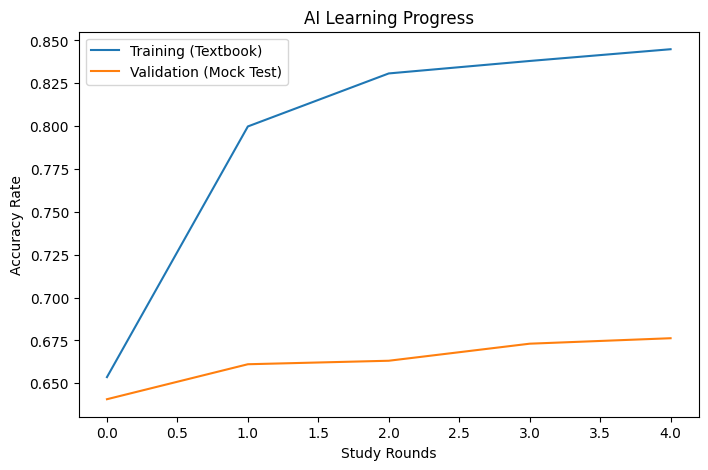

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training (Textbook)')
plt.plot(history.history['val_accuracy'], label='Validation (Mock Test)')
plt.title('AI Learning Progress')
plt.ylabel('Accuracy Rate')
plt.xlabel('Study Rounds')
plt.legend()
plt.show()